In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Chargement des données
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Chargement du modèle champion
model = joblib.load('../models/xgb_champion.pkl')

# Prédictions
y_pred = model.predict(X_test)

print("Tout chargé ✓")

Tout chargé ✓


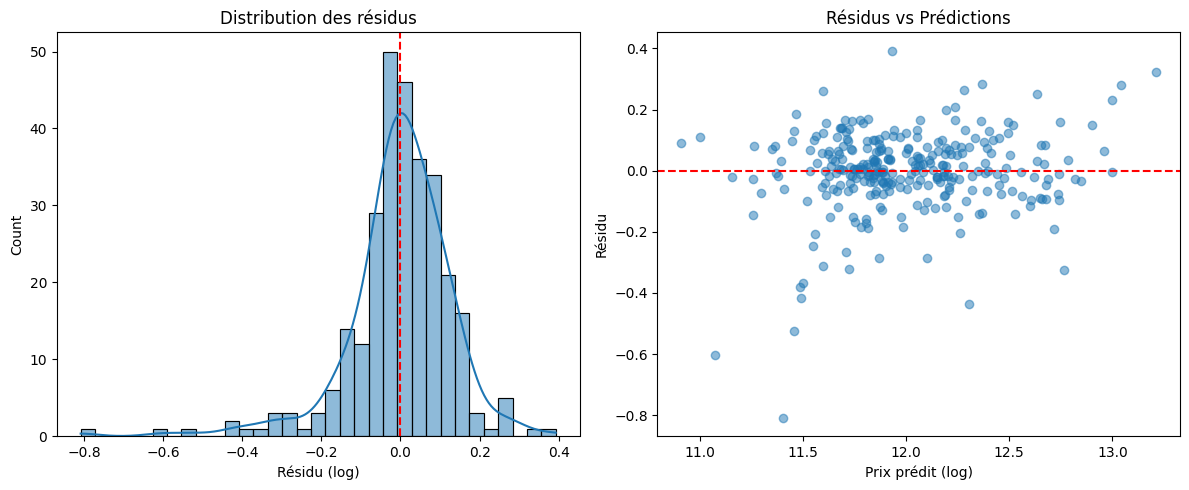

In [2]:
residus = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution des résidus
sns.histplot(residus, ax=axes[0], kde=True)
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_title('Distribution des résidus')
axes[0].set_xlabel('Résidu (log)')

# Résidus vs valeurs prédites
axes[1].scatter(y_pred, residus, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Résidus vs Prédictions')
axes[1].set_xlabel('Prix prédit (log)')
axes[1].set_ylabel('Résidu')

plt.tight_layout()
plt.show()

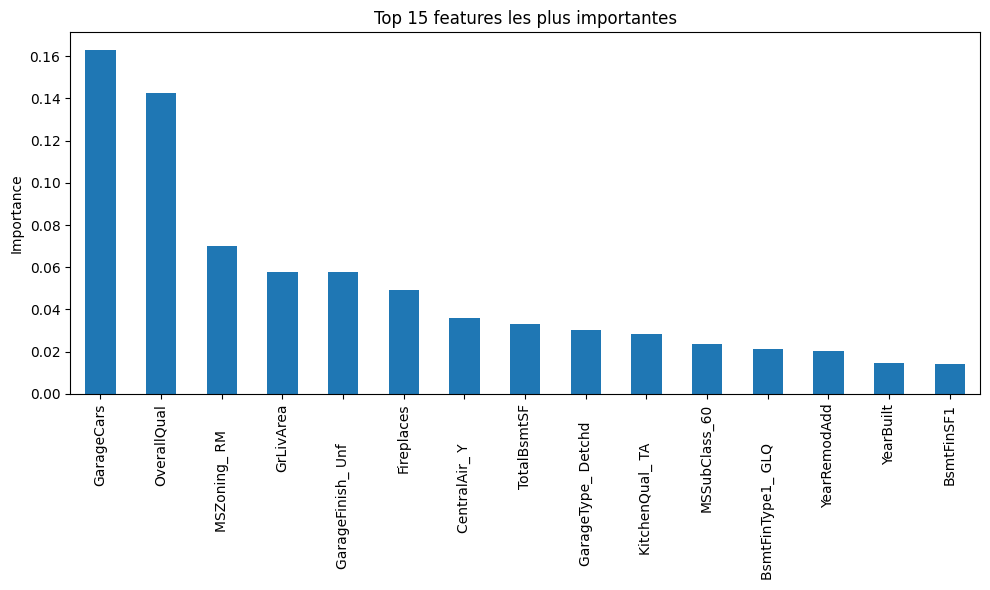

In [3]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Top 15 features les plus importantes')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [4]:
erreurs = pd.DataFrame({
    'Prix_réel': np.exp(y_test),
    'Prix_prédit': np.exp(y_pred),
    'Erreur_dollars': np.abs(np.exp(y_test) - np.exp(y_pred))
}).sort_values('Erreur_dollars', ascending=False)

print("Top 10 pires prédictions :")
print(erreurs.head(10).round(0).to_string())

Top 10 pires prédictions :
     Prix_réel  Prix_prédit  Erreur_dollars
139   755000.0     546970.0        208030.0
74    611657.0     461814.0        149843.0
168   556581.0     441160.0        115421.0
43    253293.0     350024.0         96731.0
260   395000.0     307283.0         87717.0
278   143000.0     221078.0         78078.0
6     311500.0     234777.0         76723.0
195   225000.0     151977.0         73023.0
200   280000.0     215161.0         64839.0
270   465000.0     400184.0         64816.0


In [5]:
rapport = {
    'MAE_log': 0.0895,
    'RMSE_log': 0.1331,
    'R2': 0.9051,
    'MAE_dollars': 14500,
    'points_forts': 'Maisons 100k-400k$',
    'points_faibles': 'Biens luxe >500k$'
}

import json
with open('../outputs/rapport_evaluation.json', 'w') as f:
    json.dump(rapport, f, indent=4)

print("Rapport sauvegardé ✓")

Rapport sauvegardé ✓


In [6]:
import joblib
joblib.dump(X_test.columns.tolist(), '../models/expected_columns.pkl')
print("Colonnes sauvegardées ✓")

Colonnes sauvegardées ✓
